# Data Visualization Submission  
## Python Exercises  

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Load Data
try:
    df = pd.read_csv('../data/municipalities.csv', sep=';', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('../data/municipalities.csv', sep=';', encoding='latin1')

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Data Info ---")
print(df.info())

print(df.columns)

--- First 5 Rows ---
   MunicipalityId           Name  Status         District  \
0            1508      Ipolyszog  kozseg  Balassagyarmati   
1            1526  Somoskoujfalu  kozseg     Salgotarjani   
2            2015   Rackeresztur  kozseg     Martonvasari   
3            2024       Martonyi  kozseg         Edelenyi   
4            2033         Kakasd  kozseg         Bonyhadi   

                 County  Area  Population  Latitude  Longitude  
0                Nograd   607         556   48.0546    19.2318  
1                Nograd   519        2034   48.1618    19.8242  
2                 Fejer  3530        3427   47.2739    18.8340  
3  Borsod-Abauj-Zemplen  1757         366   48.4689    20.7656  
4                 Tolna  2078        1621   46.3463    18.5927  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Mu

In [19]:
# "Jelenjenek meg a 10 legnagyobb lakosságszámú település adatai."
print("\n--- Top 10 Legnagyobb Lakosságszámú Település ---")
top_10_pop = df.nlargest(10, 'Population')[['Name', 'County', 'Population']]
print(top_10_pop)


--- Top 10 Legnagyobb Lakosságszámú Település ---
                Name                  County  Population
1120        Budapest                BUDAPEST     1706851
1273        Debrecen             Hajdu-Bihar      201432
3052          Szeged                Csongrad      160766
2767         Miskolc    Borsod-Abauj-Zemplen      154521
1693            Pecs                 Baranya      142873
2290            Gyor       Gyor-Moson-Sopron      132038
1478     Nyiregyhaza  Szabolcs-Szatmar-Bereg      116799
2400       Kecskemet             Bacs-Kiskun      110687
1242  Szekesfehervar                   Fejer       96940
93       Szombathely                     Vas       78407


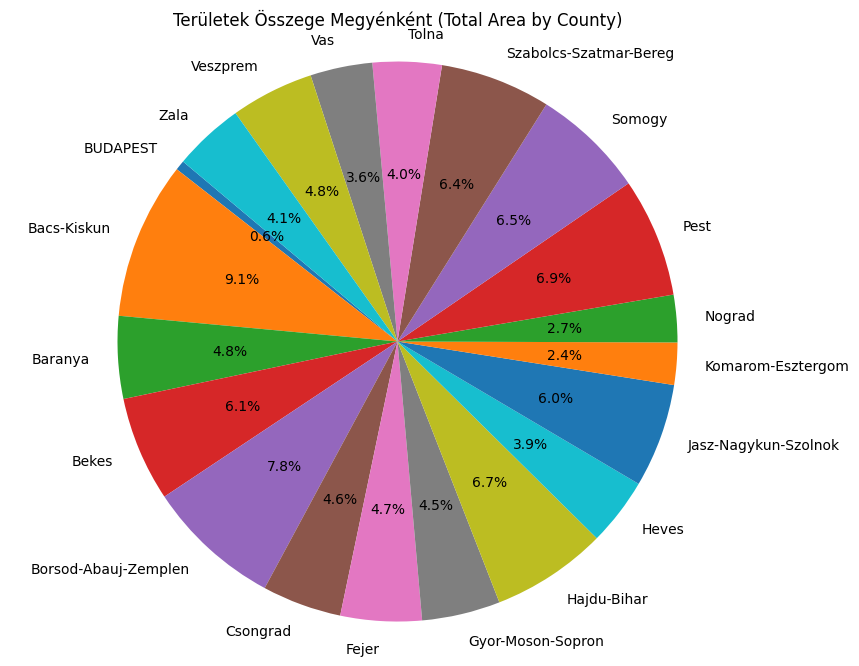

In [20]:
# "Legyen egy Pie chart, ami megyénként (County) mutatja a területek összegét."

# Aggregate Area by County
county_area = df.groupby('County')['Area'].sum()

plt.figure(figsize=(10, 8))
plt.pie(county_area, labels=county_area.index, autopct='%1.1f%%', startangle=140)
plt.title('Területek Összege Megyénként (Total Area by County)')
plt.axis('equal')
plt.show()

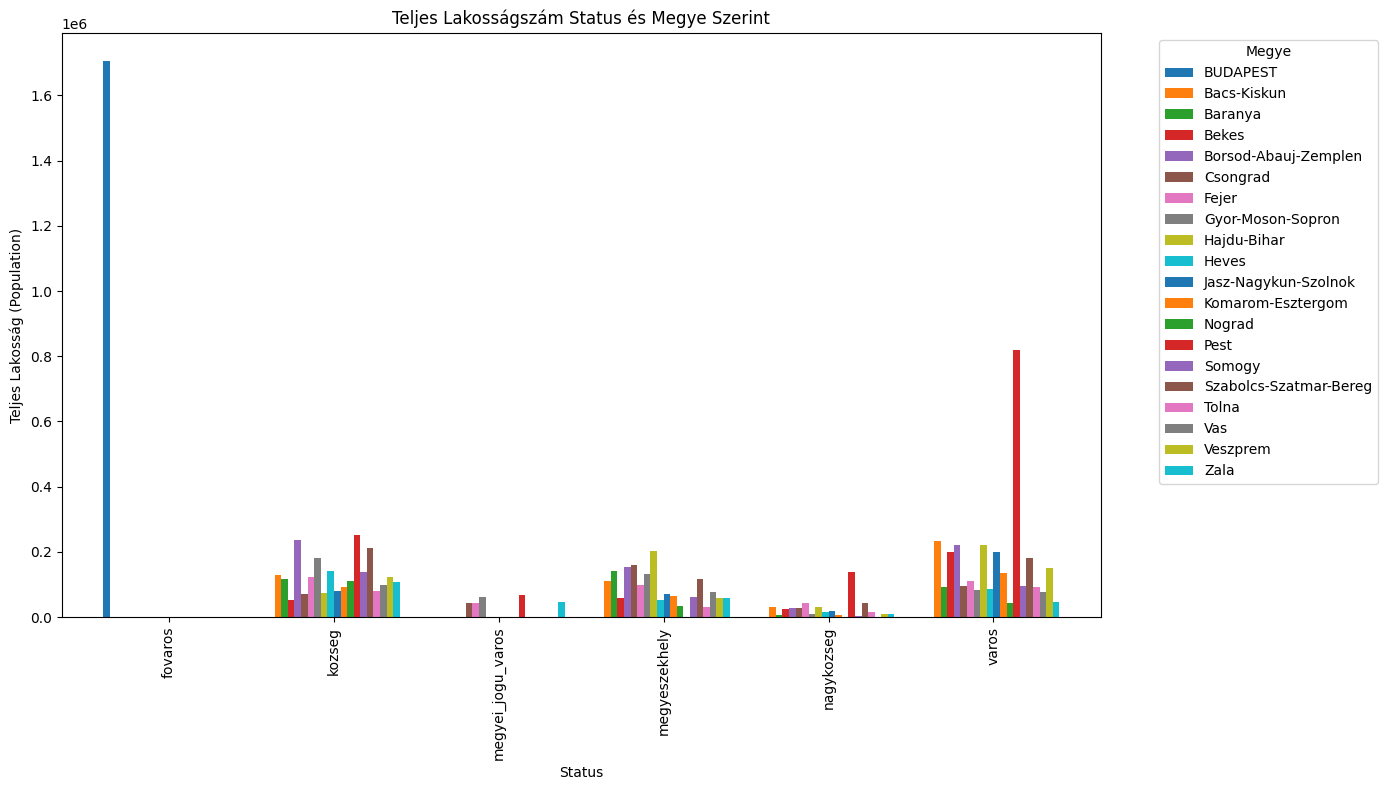

In [21]:
# "Legyen egy Clustered column chart, ami az X-tengelyen Status szerinti bontásban mutatja 
# a teljes lakosságszámot, megyék szerint tovább csoportosítva az oszlopokat."

# Group by Status and County, then sum Population
pop_by_status_county = df.groupby(['Status', 'County'])['Population'].sum().unstack()

# Plotting
# Note: Since there are many counties, the chart might be crowded. 
# We increase figure size to accommodate.
ax = pop_by_status_county.plot(kind='bar', figsize=(14, 8), width=0.8)

plt.title('Teljes Lakosságszám Status és Megye Szerint')
plt.xlabel('Status')
plt.ylabel('Teljes Lakosság (Population)')
plt.legend(title='Megye', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

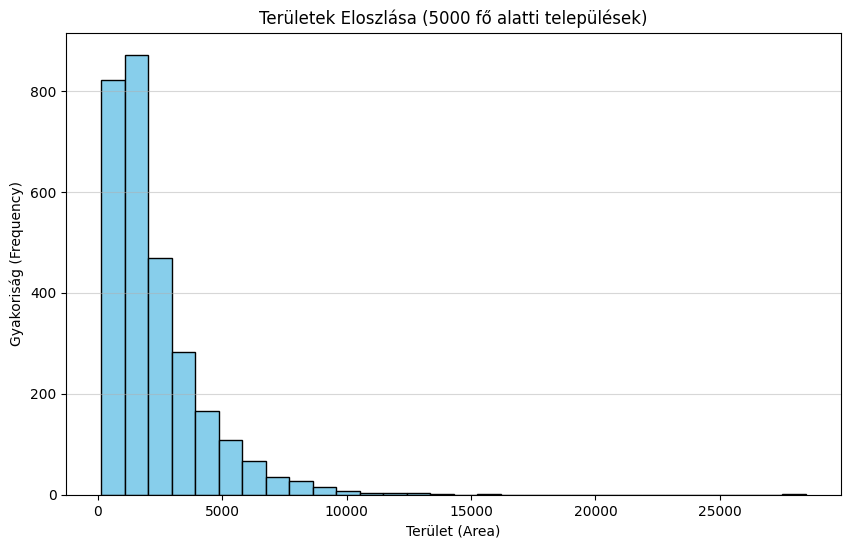

In [22]:
# "Legyen egy olyan hisztogram, ami a területek (Area) eloszlását mutatja meg 
# minden 5000 főnél kisebb település esetén."

# Filter data
small_towns = df[df['Population'] < 5000]

plt.figure(figsize=(10, 6))
plt.hist(small_towns['Area'], bins=30, color='skyblue', edgecolor='black')
plt.title('Területek Eloszlása (5000 fő alatti települések)')
plt.xlabel('Terület (Area)')
plt.ylabel('Gyakoriság (Frequency)')
plt.grid(axis='y', alpha=0.5)
plt.show()

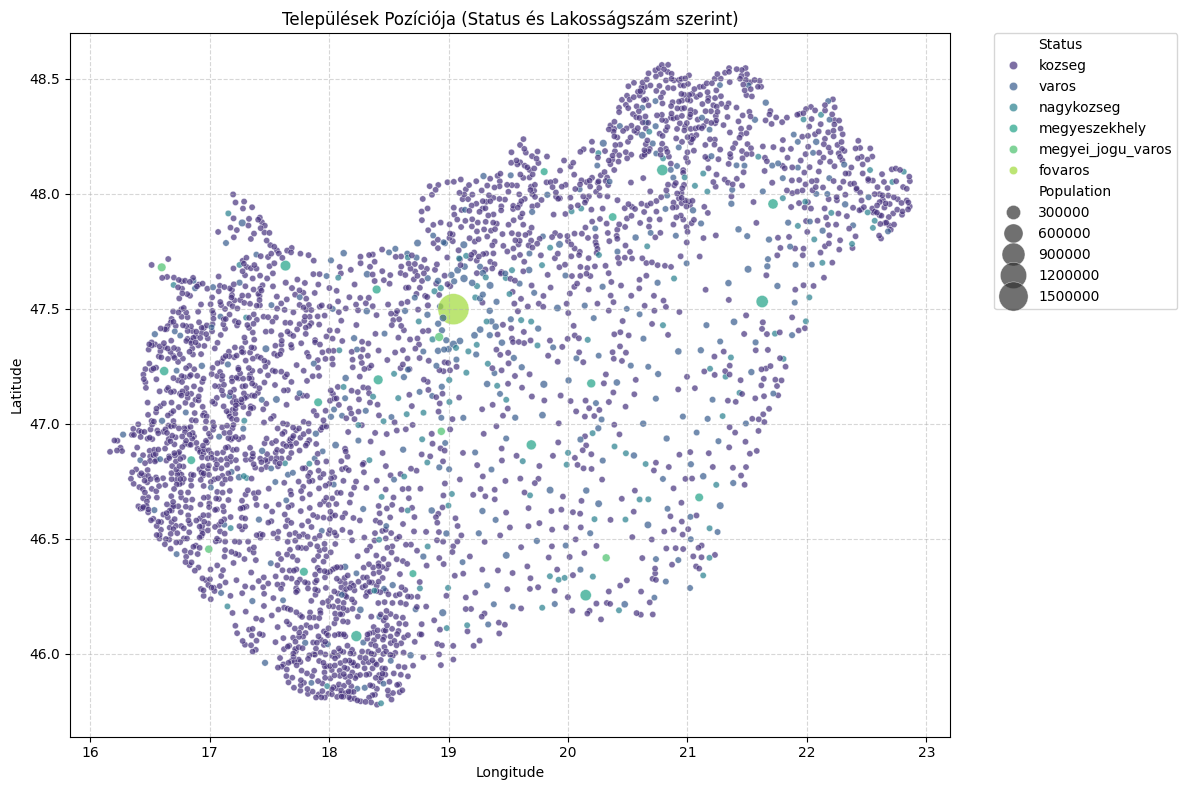

In [23]:
# "Legyen egy Scatter chart, ami mutatja a települések pozícióját. Külön stílussal jelenjen meg 
# minden különböző Status (szín és/vagy marker), és a marker mérete reflektáljon a lakosságszámra."

plt.figure(figsize=(12, 8))

# Using seaborn for easier handling of hue (color) and size
sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='Status',       # Color by Status
    size='Population',  # Size by Population
    sizes=(20, 500),    # Control the range of marker sizes
    alpha=0.7,          # Transparency
    palette='viridis'   # Color palette
)

plt.title('Települések Pozíciója (Status és Lakosságszám szerint)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()